<a href="https://colab.research.google.com/github/SubhankarBharadwaj/IITG.Ai-Submission/blob/main/iitgAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PREDICTIVE PARADOX PROJECT


By
Subhankar Bharadwaj

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime

PREPARING THE WEATHER DATASET

In [57]:
weather = pd.read_excel('weather_data.xlsx', skiprows=3)


weather = weather.drop(columns=['latitude', 'longitude', 'elevation',
                               'utc_offset_seconds', 'timezone',
                               'timezone_abbreviation'], errors='ignore')


weather.columns = ['time', 'temp', 'humidity', 'apparent_temp', 'precip',
                  'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine_dur']


weather['time'] = pd.to_datetime(weather['time'])
weather = weather.interpolate(method='linear')

print(weather.head())

                 time  temp  humidity  apparent_temp  precip  dew_point  \
0 2014-01-01 00:00:00  13.9        89           13.3     0.0       12.1   
1 2014-01-01 01:00:00  13.6        91           13.2     0.0       12.1   
2 2014-01-01 02:00:00  13.3        91           12.8     0.0       11.9   
3 2014-01-01 03:00:00  13.0        92           12.5     0.0       11.8   
4 2014-01-01 04:00:00  12.7        93           12.2     0.0       11.6   

   soil_temp  wind_dir  cloud_cover  sunshine_dur  
0       16.4       313            0           0.0  
1       16.0       317            0           0.0  
2       15.7       317            0           0.0  
3       15.4       319            0           0.0  
4       15.2       322            0           0.0  


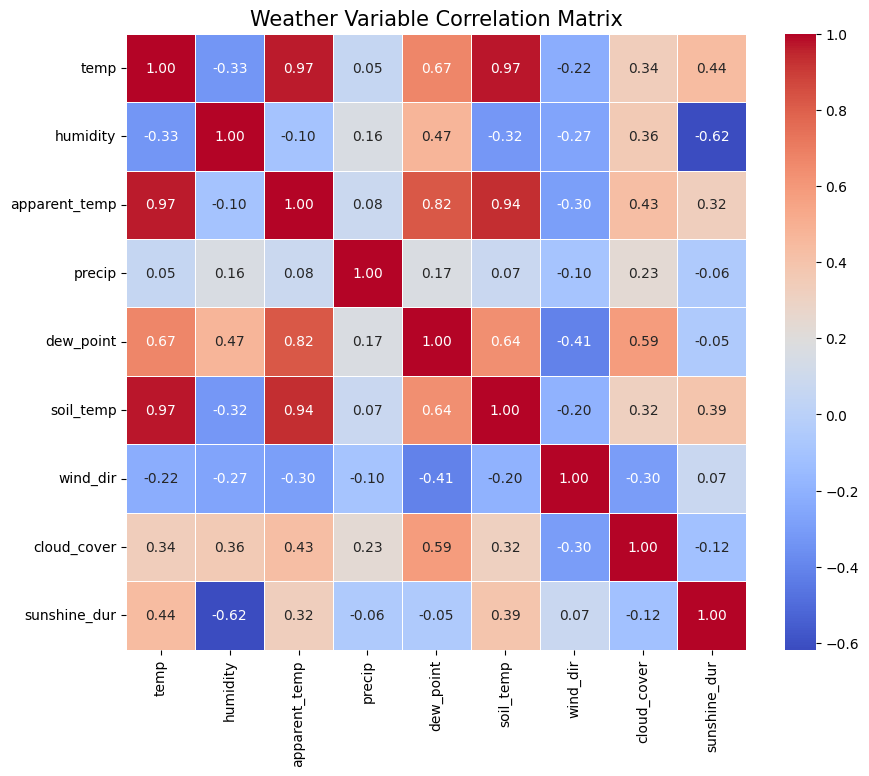

In [58]:
corr_matrix = weather.drop(columns=['time']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap='coolwarm', linewidths=0.5)

plt.title('Weather Variable Correlation Matrix', fontsize=15)
plt.show()

In [59]:
#Since temp, apparent temp and soil temp have very high correlation, we can remove apparent temp and soil temp
weather = weather.drop(columns=['apparent_temp', 'soil_temp'])


PREPARING THE DEMAND DATASET

In [60]:
demand_df = pd.read_excel('PGCB_date_power_demand.xlsx')
demand_df['datetime'] = pd.to_datetime(demand_df['datetime'])
demand_df = demand_df.sort_values(by='datetime').reset_index(drop=True)
renewable_cols = ['solar', 'wind', 'hydro']
demand_df[renewable_cols] = demand_df[renewable_cols].fillna(0)
demand_df['is_peak'] = demand_df['remarks'].notna().astype(int)#creating a new column to mark peaks

print(demand_df.head())

             datetime  generation_mw  demand_mw  load_shedding  gas  \
0 2015-04-19 00:00:00         4821.0       4821              0    0   
1 2015-04-19 01:00:00         3612.0       3612              0    0   
2 2015-04-19 02:00:00         3727.0       3727              0    0   
3 2015-04-19 03:00:00         3632.0       3632              0    0   
4 2015-04-19 04:00:00         3641.0       3641              0    0   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    0.0   0.0                     0              0   
1            0     0      0    0.0   0.0                     0              0   
2            0     0      0    0.0   0.0                     0              0   
3            0     0      0    0.0   0.0                     0              0   
4            0     0      0    0.0   0.0                     0              0   

   india_adani  nepal remarks  is_peak  
0          NaN    NaN     NaN        0  
1   

In [61]:
potential_useless_cols = ['load_shedding', 'nepal', 'india_tripura', 'india_adani', 'solar', 'wind']

for col in potential_useless_cols:
    if col in demand_df.columns:
        missing_pct = (demand_df[col].isna().sum() + (demand_df[col] == 0).sum()) / len(demand_df) * 100

        if missing_pct > 95:
            print(f"Dropping {col}: {missing_pct:.2f}% of data is missing or zero.")
            demand_df = demand_df.drop(columns=[col])
        else:
            print(f"Keeping {col}: Only {missing_pct:.2f}% is missing/zero.")
if 'remarks' in demand_df.columns:
    demand_df = demand_df.drop(columns=['remarks'])

Keeping load_shedding: Only 84.02% is missing/zero.
Dropping nepal: 99.92% of data is missing or zero.
Keeping india_tripura: Only 9.75% is missing/zero.
Keeping india_adani: Only 92.14% is missing/zero.
Keeping solar: Only 64.58% is missing/zero.
Keeping wind: Only 86.96% is missing/zero.


In [62]:
generation_sources = ['india_adani', 'india_tripura', 'solar', 'wind', 'load_shedding']

for col in generation_sources:
    if col in demand_df.columns:
        demand_df[col] = demand_df[col].fillna(0)

#filled nan values with 0 for nonuseless columns

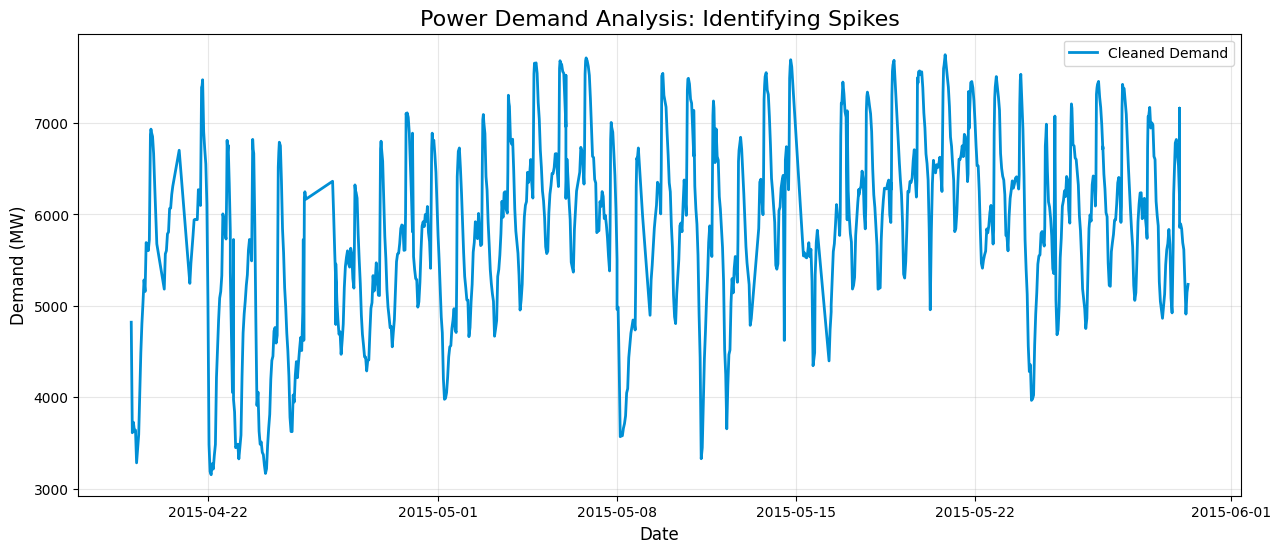

In [63]:
plt.figure(figsize=(15, 6))
plt.plot(demand_df['datetime'][:1000], demand_df['demand_mw'][:1000],
         label='Cleaned Demand', color='#008fd5', linewidth=2)
plt.title('Power Demand Analysis: Identifying Spikes', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand (MW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [64]:
def clean_with_hampel(df, column, window_size=24, n_sigmas=3):

    new_series = df[column].copy()
    rolling_median = df[column].rolling(window=window_size, center=True).median()
    def get_mad(x):
        return np.median(np.abs(x - np.median(x)))

    rolling_mad = df[column].rolling(window=window_size, center=True).apply(get_mad)
    lower_bound = rolling_median - (n_sigmas * 1.4826 * rolling_mad)
    upper_bound = rolling_median + (n_sigmas * 1.4826 * rolling_mad)
    is_spike = (df[column] > upper_bound) | (df[column] < lower_bound)
    new_series[is_spike] = rolling_median[is_spike]

    print(f"Hampel Filter detected and cleaned {is_spike.sum()} spikes.")
    return new_series
demand_df['demand_mw'] = clean_with_hampel(demand_df, 'demand_mw')

Hampel Filter detected and cleaned 876 spikes.


/tmp/ipykernel_4105/1719571104.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 5222.   5222.   5222.   6279.   5535.   5535.   5535.   6552.5  6372.
  6490.5  6490.5  6490.5  6164.5  6075.5  6165.   4533.   4533.   4533.
  4533.   4907.   5121.5  5121.5  5121.5  5121.5  5121.5  5888.   4667.
  4667.   5794.   5794.   5794.   5794.   6262.5  6262.5  6262.5  6262.5
  6262.5  6454.5  6454.5  6454.5  6662.5  6662.5  6794.   6794.   6500.
  6466.   6466.   6466.   6230.5  6230.5  6230.5  6230.5  6328.   6328.
  6328.   6475.5  6475.5  6190.   6090.   6090.   6090.   6268.5  4753.5
  4753.5  4753.5  4753.5  4753.5  4753.5  4339.5  4339.5  4339.5  4339.5
  4339.5  4380.   4206.   4206.   4206.   4206.   4207.5  4213.   4059.
  4059.   4059.   4059.   4073.5  4127.5  4999.   4999.   4124.5  4124.5
  4124.5  4124.5  4078.5  4124.5  4553.5  4553.5  4553.5  4553.5  4139.
  4139.   4139.   4023.   3859.   385

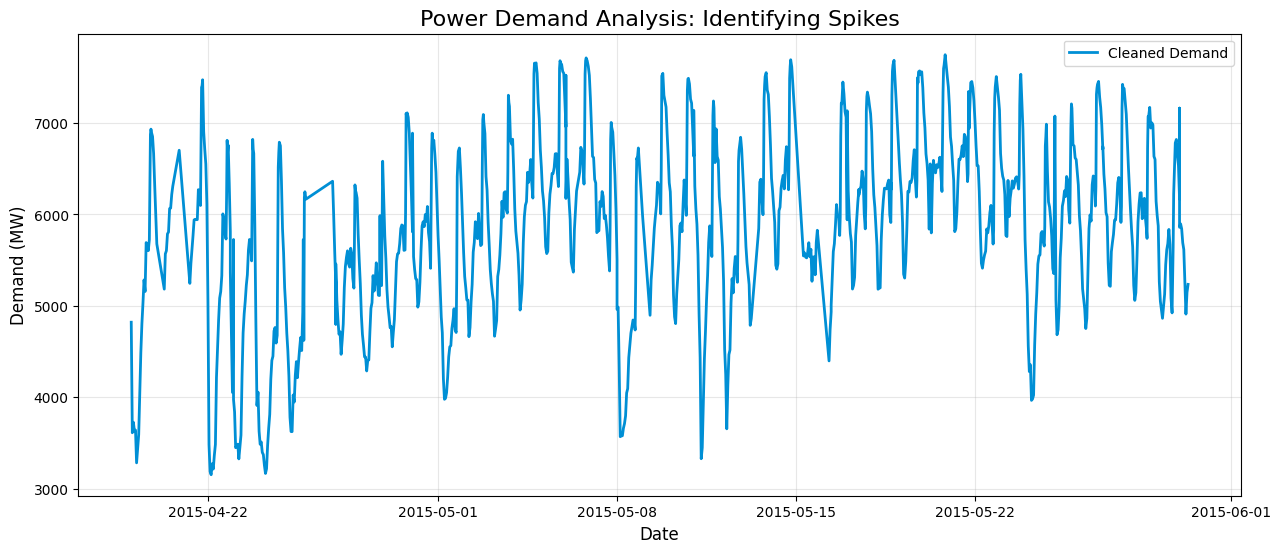

In [65]:
plt.figure(figsize=(15, 6))
plt.plot(demand_df['datetime'][:1000], demand_df['demand_mw'][:1000],
         label='Cleaned Demand', color='#008fd5', linewidth=2)
plt.title('Power Demand Analysis: Identifying Spikes', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand (MW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
#i dont see any change in the graph tbh lol

In [66]:
demand_df['target_next_hour'] = demand_df['demand_mw'].shift(-1)
print(demand_df['target_next_hour'].isna().sum())
#this value of 1 is arriving coz of the last row

1


In [67]:
demand_df = demand_df.dropna(subset=['target_next_hour'])

MERGING WEATHER DATASET AND DEMAND DATASET

In [68]:
merged_df = pd.merge(demand_df, weather, left_on='datetime', right_on='time', how='inner')
merged_df = merged_df.drop(columns=['time'])

#The merged dataset is created

PREPARING THE ECONOMIC DATASET

In [69]:
eco_df = pd.read_csv('economic_full_1.csv')
key_indicators = ['NY.GDP.MKTP.KD.ZG', 'SP.POP.TOTL']
eco_filtered = eco_df[eco_df['Indicator Code'].isin(key_indicators)]

eco_t = eco_filtered.set_index('Indicator Code').iloc[:, 4:].T
eco_t.index.name = 'Year'
eco_t.columns = ['GDP_Growth', 'Total_Population']

eco_t = eco_t.reset_index()
eco_t['Year'] = eco_t['Year'].astype(int)
eco_t = eco_t.sort_values(by='Year')
eco_t = eco_t.fillna(method='ffill').fillna(method='bfill')

eco_t.tail()

/tmp/ipykernel_4105/776766015.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  eco_t = eco_t.fillna(method='ffill').fillna(method='bfill')


,Year,GDP_Growth,Total_Population
59,2021,167658854.0,6.938679
60,2022,169384897.0,7.099829
61,2023,171466990.0,5.775112
62,2024,173562364.0,4.223259
63,2025,173562364.0,4.223259


In [70]:
merged_df['Year'] = merged_df['datetime'].dt.year

final_df = pd.merge(merged_df, eco_t, on='Year', how='left')
final_df = final_df.dropna()

#The final dataset is created

FEATURE ENGINEERING

In [71]:
final_df['hour'] = final_df['datetime'].dt.hour
final_df['day_of_week'] = final_df['datetime'].dt.dayofweek
final_df['month'] = final_df['datetime'].dt.month

final_df['lag_1h'] = final_df['demand_mw'].shift(1)
final_df['lag_24h'] = final_df['demand_mw'].shift(24)
final_df['lag_week'] = final_df['demand_mw'].shift(168)

final_df['recent_trend_avg'] = (final_df['lag_1h'] +
                                final_df['lag_24h'] +
                                final_df['lag_week']) / 3

def get_day_period(hour):
    if 6 <= hour < 12: return 1 # Morning
    if 12 <= hour < 17: return 2 # Afternoon
    if 17 <= hour < 22: return 3 # Evening (Peak)
    else: return 0 # Night

final_df['day_period'] = final_df['datetime'].dt.hour.apply(get_day_period)
final_df['is_weekend'] = final_df['datetime'].dt.dayofweek.isin([5, 6]).astype(int)
final_df['is_winter'] = final_df['datetime'].dt.month.isin([12, 1, 2]).astype(int)

final_df = final_df.dropna()

TRAIN TEST SPLIT

In [72]:
train_data = final_df[final_df['datetime'] < '2024-01-01']
test_data = final_df[final_df['datetime'] >= '2024-01-01']

features = [
    'demand_mw', 'temp', 'humidity', 'hour','day_of_week', 'month',
    'is_peak', 'is_weekend', 'is_winter', 'day_period',
    'lag_1h', 'lag_24h', 'GDP_Growth', 'Total_Population', 'lag_week',
    'recent_trend_avg'
]

X_train = train_data[features]
y_train = train_data['target_next_hour']

X_test = test_data[features]
y_test = test_data['target_next_hour']



MODEL TRAINING

In [73]:
xgb_model= xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,
    random_state=42
)


xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_round=50,
    random_state=42
)

lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
lgb_mae = mean_absolute_error(y_test, lgb_preds)

print("XGBoost MAE: ", xgb_mae)
print("LightGBM MAE: ", lgb_mae)

[0]	validation_0-rmse:3743.32058
[100]	validation_0-rmse:372.82146
[200]	validation_0-rmse:338.49517
[300]	validation_0-rmse:329.39579
[400]	validation_0-rmse:326.20157
[500]	validation_0-rmse:326.07950
[505]	validation_0-rmse:326.22500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1682
[LightGBM] [Info] Number of data points in the train set: 75497, number of used features: 16
[LightGBM] [Info] Start training from score 8307.397022
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[832]	valid_0's l2: 98754.8
XGBoost MAE:  221.7652967840789
LightGBM MAE:  214.99630528279116


Since LightGBM MAE is lower, so we choose it

In [74]:
best_model = lgb_model
best_preds = lgb_preds

def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

final_mape = calculate_mape(y_test, best_preds)
print("Final Evaluation on 2024 Test Set (MAPE): ", final_mape)

Final Evaluation on 2024 Test Set (MAPE):  1.8689659009754012


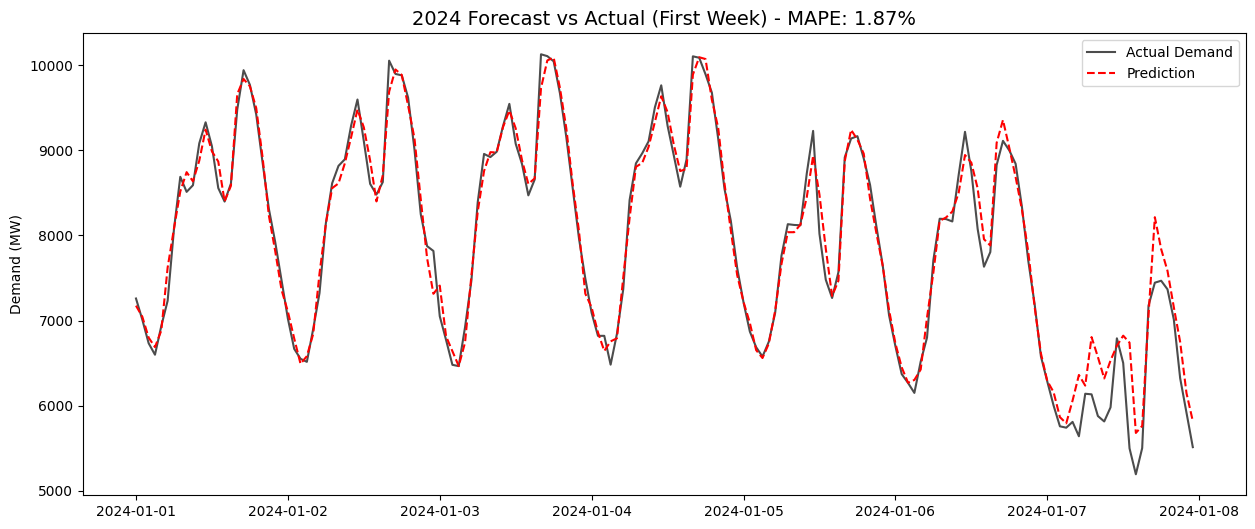

In [75]:
plt.figure(figsize=(15, 6))
plt.plot(test_data['datetime'][:168], y_test[:168], label='Actual Demand', color='black', alpha=0.7)
plt.plot(test_data['datetime'][:168], best_preds[:168], label='Prediction', color='red', linestyle='--')

plt.title(f'2024 Forecast vs Actual (First Week) - MAPE: {final_mape:.2f}%', fontsize=14)
plt.ylabel('Demand (MW)')
plt.legend()
plt.show()